In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier,
                              VotingClassifier, StackingClassifier,HistGradientBoostingClassifier)
from sklearn.metrics import accuracy_score, f1_score, classification_report

sns.set_style("whitegrid")

### Task 1: Baseline with Single Models

Load the data and establish individual model baselines.

1. Load the Wine Quality dataset and create a binary target:

```python
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=";")
wine["quality_label"] = (wine["quality"] >= 7).astype(int)  # 1 = good, 0 = not good
```

2. Explore the dataset: how many features? What's the class distribution of `quality_label`? Is the dataset imbalanced?
3. Separate features and target. Drop the original `quality` column.
4. Split into training and test sets (80/20, `stratify=y`, `random_state=42`).
5. Scale features using `StandardScaler`.
6. Fit three baseline models:
   - `DecisionTreeClassifier(random_state=42)`
   - `LogisticRegression(max_iter=1000, random_state=42)`
   - `KNeighborsClassifier()`

7. Report **accuracy** and **F1 score** (use `f1_score` with `average="binary"`) for each on the test set. Organize results in a table.


In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=";")
wine["quality_label"] = (wine["quality"] >= 7).astype(int)  # 1 = good, 0 = not good

In [3]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [4]:
n_features = wine.shape[1] - 1 
class_dist = wine["quality_label"].value_counts()
class_ratio = wine["quality_label"].value_counts(normalize=True)

print("Number of features:", n_features)
print("\nClass counts:\n", class_dist)
print("\nClass ratio:\n", class_ratio)

Number of features: 12

Class counts:
 quality_label
0    1382
1     217
Name: count, dtype: int64

Class ratio:
 quality_label
0    0.86429
1    0.13571
Name: proportion, dtype: float64


In [5]:
X = wine.drop(columns=["quality", "quality_label"])
y = wine["quality_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
dt = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)
knn = KNeighborsClassifier()

dt.fit(X_train, y_train)                 
lr.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [8]:
models = {
    "Decision Tree": dt,
    "Logistic Regression": lr,
    "KNN": knn
}

results = []

for name, model in models.items():
    if name == "Decision Tree":
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="binary")
    
    results.append([name, acc, f1])

baseline_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])
baseline_df

,Model,Accuracy,F1 Score
0,Decision Tree,0.90000,0.644444
1,Logistic Regression,0.89375,0.484848
2,KNN,0.89375,0.514286


### Task 2: Bagging & Random Forest

Explore how bagging improves on individual decision trees.

1. Fit a `BaggingClassifier` with a `DecisionTreeClassifier` as the base estimator (`n_estimators=100`, `oob_score=True`, `random_state=42`).
2. Fit a `RandomForestClassifier` (`n_estimators=100`, `oob_score=True`, `random_state=42`).
3. For both models, report:
   - Out-of-bag (OOB) score
   - Test accuracy and F1 score
4. Compare: How does bagging improve over the single Decision Tree from Task 1?
5. Plot the **top 10 feature importances** from the Random Forest as a horizontal bar chart. Which features matter most for predicting wine quality?
6. In a markdown cell, explain: Why does Random Forest typically outperform a single Decision Tree? What role does randomness play?


In [9]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    oob_score=True,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42
)

bagging.fit(X_train, y_train)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [10]:
models = {
    "Bagging": bagging,
    "Random Forest": rf
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    oob = model.oob_score_
    
    results.append([name, oob, acc, f1])

bagging_df = pd.DataFrame(results, columns=["Model", "OOB Score", "Accuracy", "F1 Score"])
bagging_df = bagging_df.drop(columns=["OOB Score"])
bagging_df

,Model,Accuracy,F1 Score
0,Bagging,0.93750,0.736842
1,Random Forest,0.94375,0.750000


In [11]:
y_pred_dt = dt.predict(X_test)
y_pred_bag = bagging.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

bag_acc = accuracy_score(y_test, y_pred_bag)
bag_f1 = f1_score(y_test, y_pred_bag)

comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Bagging"],
    "Accuracy": [dt_acc, bag_acc],
    "F1 Score": [dt_f1, bag_f1]
})

improvement = pd.DataFrame({
    "Metric": ["Accuracy", "F1 Score"],
    "Bagging Improvement": [
        bag_acc - dt_acc,
        bag_f1 - dt_f1
    ]
})

print("Comparison:")
print(comparison)

print("\nImprovement:")
print(improvement)

Comparison:
           Model  Accuracy  F1 Score
0  Decision Tree    0.9000  0.644444
1        Bagging    0.9375  0.736842

Improvement:
     Metric  Bagging Improvement
0  Accuracy             0.037500
1  F1 Score             0.092398


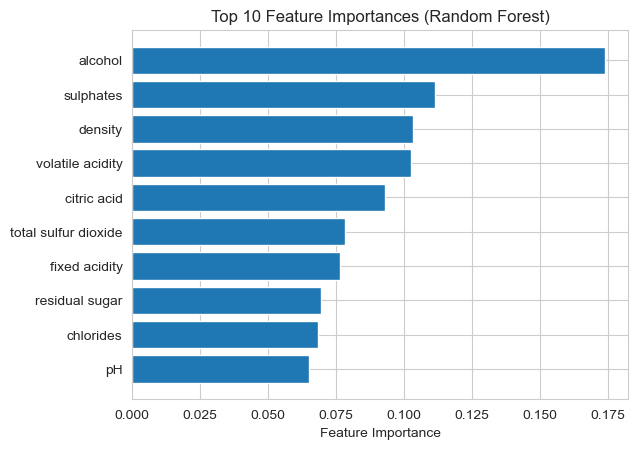

In [12]:
importances = rf.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)[-10:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

A single Decision Tree can easily **overfit** the training data, which means it learns noise and does not perform well on new data.

Random Forest solves this by using **many trees instead of one** and combining their predictions. This makes the model:

- More stable  
- Less likely to overfit  
- Better at generalizing to new data  

Random Forest uses randomness in two ways:

1. **Different data for each tree** (bootstrap sampling)  
2. **Different features at each split**


 Why does this help?

- Trees become **different from each other**  
- Mistakes made by one tree are corrected by others  
- Overall predictions become more accurate  

So, Random Forest usually performs better than a single Decision Tree.

### Task 3: Boosting

Train boosting models and analyze how they learn.

1. Fit the following boosting models:
   - `AdaBoostClassifier(n_estimators=100, random_state=42)`
   - `GradientBoostingClassifier(n_estimators=100, random_state=42)`
   - (Optional) `HistGradientBoostingClassifier(max_iter=100, random_state=42)` — scikit-learn's faster implementation

2. Report accuracy and F1 for each on the test set.

3. **Learning curves:** For `GradientBoostingClassifier`, use `staged_predict` to compute training and test accuracy at each boosting stage (1 to 100 estimators). Plot both curves on the same figure. At what point does the model start to overfit (if at all)?

4. In a markdown cell, compare AdaBoost and GradientBoosting: How do they differ in their approach? When might you prefer one over the other?


In [13]:
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
hgb = HistGradientBoostingClassifier(max_iter=100, random_state=42)

ada.fit(X_train, y_train)
gb.fit(X_train, y_train)
hgb.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
y_pred_gb = gb.predict(X_test)
y_pred_hgb = hgb.predict(X_test)

boosting_df = pd.DataFrame({
    "Model": ["AdaBoost", "Gradient Boosting", "HistGradientBoosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_ada),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_hgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_ada),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_hgb)
    ]
})

boosting_df


,Model,Accuracy,F1 Score
0,AdaBoost,0.893750,0.433333
1,Gradient Boosting,0.915625,0.619718
2,HistGradientBoosting,0.946875,0.773333


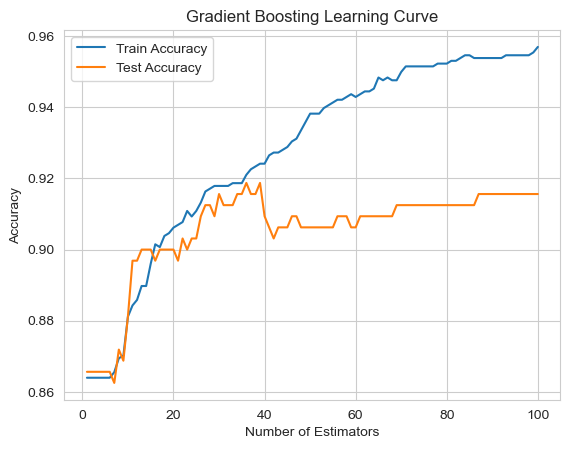

In [14]:
train_acc = []
test_acc = []

for y_train_pred, y_test_pred in zip(
    gb.staged_predict(X_train),
    gb.staged_predict(X_test)
):
    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))

plt.figure()
plt.plot(range(1, 101), train_acc, label="Train Accuracy")
plt.plot(range(1, 101), test_acc, label="Test Accuracy")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting Learning Curve")
plt.legend()
plt.show()

 AdaBoost vs Gradient Boosting

- **AdaBoost** increases the weight of misclassified samples  
- **Gradient Boosting** learns by correcting previous errors (residuals)  

 When to use?

- **AdaBoost** → simpler, faster, less complex problems  
- **Gradient Boosting** → better performance, handles complex patterns  

 Based on results

Gradient Boosting performs better (higher F1), meaning it predicts the minority class more effectively.

### Task 4: Stacking & Voting

Combine your best models into meta-ensembles.

1. **Voting classifier:** Select the 3 best-performing models from Tasks 1–3. Build a `VotingClassifier` with `voting="soft"`. Report accuracy and F1 on the test set.

2. **Stacking classifier:** Using the same 3 base models, build a `StackingClassifier` with `LogisticRegression()` as the `final_estimator`. Report accuracy and F1 on the test set.

3. **Final comparison table:** Create a comprehensive DataFrame comparing **all** models from the entire lab (baselines, bagging, Random Forest, boosting, voting, stacking) with their accuracy and F1 scores. Sort by F1 descending.

4. In a concluding markdown cell, answer:
   - Which ensemble strategy performed best on this dataset?
   - Was the improvement over single models significant?
   - What are the trade-offs (training time, interpretability, complexity) of using ensemble methods?
   - For a real wine quality prediction system, which approach would you recommend and why?


In [15]:
voting = VotingClassifier(
    estimators=[
        ("rf", rf),
        ("gb", gb),
        ("hgb", hgb)
    ],
    voting="soft"
)

voting.fit(X_train, y_train)

y_pred_voting = voting.predict(X_test)

voting_acc = accuracy_score(y_test, y_pred_voting)
voting_f1 = f1_score(y_test, y_pred_voting)

print("Voting Accuracy:", voting_acc)
print("Voting F1:", voting_f1)

Voting Accuracy: 0.95
Voting F1: 0.7837837837837838


In [16]:
stacking = StackingClassifier(
    estimators=[
        ("rf", rf),
        ("gb", gb),
        ("hgb", hgb)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    passthrough=False
)

stacking.fit(X_train, y_train)

y_pred_stack = stacking.predict(X_test)

stack_acc = accuracy_score(y_test, y_pred_stack)
stack_f1 = f1_score(y_test, y_pred_stack)

print("Stacking Accuracy:", stack_acc)
print("Stacking F1:", stack_f1)

Stacking Accuracy: 0.946875
Stacking F1: 0.7605633802816901


In [17]:
meta_df = pd.DataFrame([
    ["Voting", voting_acc, voting_f1],
    ["Stacking", stack_acc, stack_f1]
], columns=["Model", "Accuracy", "F1 Score"])
meta_df

,Model,Accuracy,F1 Score
0,Voting,0.950000,0.783784
1,Stacking,0.946875,0.760563


In [18]:
final_results = pd.concat([
    baseline_df,
    bagging_df,
    boosting_df,
    meta_df
])

final_results = final_results.sort_values(by="F1 Score", ascending=False)
final_results

,Model,Accuracy,F1 Score
0,Voting,0.950000,0.783784
2,HistGradientBoosting,0.946875,0.773333
1,Stacking,0.946875,0.760563
1,Random Forest,0.943750,0.750000
0,Bagging,0.937500,0.736842
0,Decision Tree,0.900000,0.644444
1,Gradient Boosting,0.915625,0.619718
2,KNN,0.893750,0.514286
1,Logistic Regression,0.893750,0.484848
0,AdaBoost,0.893750,0.433333


**Best ensemble strategy:**  
Voting performed the best with the highest F1 score (0.78), slightly outperforming HistGradientBoosting and Stacking.

**Improvement over single models:**  
Yes, the improvement was significant.  
Single models like Decision Tree (F1 ≈ 0.64) performed much worse compared to ensemble methods (F1 ≈ 0.75–0.78).  
This shows ensembles handle the minority class much better.

**Trade-offs:**
- **Training time:** higher (especially boosting & stacking)  
- **Interpretability:** lower (harder to understand decisions)  
- **Complexity:** higher (more tuning and computation needed)  

**Recommendation:**  
For a real wine quality prediction system, **Voting or HistGradientBoosting** would be the best choice.  

- Voting → best overall performance  
- HistGradientBoosting → almost as good, but simpler and faster  

So, HistGradientBoosting is often preferred in practice due to its strong performance and lower complexity.